# MegaGO Exploration: Module Network Visualization

This notebook explores how the number of GO terms used for MegaGO similarity affects module clustering.
We compare **top 10**, **top 20**, **top 30**, and **all** enriched GO BP terms per module.

Modules are colored by **MegaGO-based hierarchical clusters** (instead of keyword-based GO categories).

**Prerequisites:**
- Run `Module_Overview_Generator.ipynb` first to generate the module overview CSV
- Cytoscape must be running for the Cytoscape visualization sections
- MegaGO installed in `LemonIte` conda environment

**Required Input Files:**
- `Module_Overview_Complete.csv` - Generated by Module_Overview_Generator.ipynb
- `Enrichr_all_enriched_pathways_up_per_module.csv` - Full pathway enrichment data

In [1]:
# Import Required Libraries
import pandas as pd
import numpy as np
import os
import sys
import shutil
import warnings
import re
import glob
import subprocess
import itertools
from concurrent.futures import ThreadPoolExecutor, as_completed
from scipy.cluster.hierarchy import linkage, fcluster, dendrogram
from scipy.spatial.distance import squareform
import matplotlib.pyplot as plt


In [2]:
# Configuration

base_dir = '/home/borisvdm/Documents/PhD/Lemonite/Wang_GBM/results/LemonTree/noProteomics_percentile2_divide_by_sum/'
os.chdir(base_dir)

# Input files
module_overview_file = 'Module_Overview_Complete.csv'
enrichment_all_file = './Enrichment/Modules_enrichr/Enrichr_all_enriched_pathways_up_per_module.csv'

# Output directory
output_dir = './Networks/megaGO_exploration'
os.makedirs(output_dir, exist_ok=True)

# MegaGO configurations to explore
megago_configs = {
    'top_10': 10,
    'top_20': 20,
    'top_30': 30,
    'all': None  # None means use all terms
}

# Regulator score files
percentile = 2
TF_score_file = f'./Lemon_out/Lovering.percentile{percentile}.txt'
metabolite_score_file = f'./Lemon_out/Metabolite.percentile{percentile}.txt'
lipid_score_file = f'./Lemon_out/Lipid.percentile{percentile}.txt'

print("Configuration loaded!")
print(f"Working directory: {base_dir}")
print(f"Output directory: {output_dir}")

Configuration loaded!
Working directory: /home/borisvdm/Documents/PhD/Lemonite/Wang_GBM/results/LemonTree/noProteomics_percentile2_divide_by_sum/
Output directory: ./Networks/megaGO_exploration


In [3]:
# Load Module Overview Data
module_overview = pd.read_csv(module_overview_file, sep='\t')

"""
modules_to_process = module_overview['Module'].unique().tolist()

# ===== TEST WITH 3 MODULES =====
modules_to_process = modules_to_process[:3]  # Limit to first 3 modules for testing
module_overview = module_overview[module_overview['Module'].isin(modules_to_process)]  # Filter data accordingly
# ================================

print(f"Loaded module overview with {len(modules_to_process)} modules")
"""
modules_to_process = module_overview['Module'].unique().tolist()
print(f"Columns: {list(module_overview.columns)}")
module_overview.head()

Columns: ['Module', 'TF_regulators', 'Metabolite_regulators', 'Lipid_regulators', 'Expression_p_adjusted', 'Expression_rank', 'Expression_test_type', 'Expression_significant', 'PPI_FDR', 'PPI_fold_enrichment', 'Module_genes', 'Top_3_pathways_bio_process', 'Top_3_pathways_molecular_function', 'Top_3_pathways_cellular_component', 'Top_3_pathways_KEGG', 'Top_3_pathways_Reactome']


,Module,TF_regulators,Metabolite_regulators,Lipid_regulators,Expression_p_adjusted,Expression_rank,Expression_test_type,Expression_significant,PPI_FDR,PPI_fold_enrichment,Module_genes,Top_3_pathways_bio_process,Top_3_pathways_molecular_function,Top_3_pathways_cellular_component,Top_3_pathways_KEGG,Top_3_pathways_Reactome
0,7,TFAP2A|SNAI1|ZBTB8B|IRF6|FOXN1|ZNF215|FOXO6|SP7,creatinine,PE(16_0/22_6)|PC(16_0/16_1)_C|PC(16_0/16_1)_B|...,1.233980e-07,1,Kruskal-Wallis H-test,Yes,3.352941e-111,4.474665,TNFRSF11B|P4HA3|KCNK15|HAS3|CFI|MET|ARHGEF5|AC...,['Extracellular Matrix Organization (GO:003019...,['Platelet-Derived Growth Factor Binding (GO:0...,['Collagen-Containing Extracellular Matrix (GO...,"['Protein digestion and absorption_Up', 'Prote...","['Extracellular Matrix Organization_Up', 'Coll..."
1,2,CUX2|SOHLH1|MYT1L|DACH2|OLIG1,creatinine|L_cysteine|linoleic_acid,PC(18_1/36_6)|PC(20_4/36_5)|PS(20_4/22_6)|PE(1...,1.233980e-07,2,Kruskal-Wallis H-test,Yes,2.087947e-38,4.082854,REPS2|VSTM2B|RIMS2|HMGCLL1|LINGO2|SAMD12|DACH2...,"['Synapse Organization (GO:0050808)_Up', 'Chlo...",['Voltage-Gated Potassium Channel Activity (GO...,['Voltage-Gated Potassium Channel Complex (GO:...,"['Neuroactive ligand-receptor interaction_Up',...","['Neuronal System_Up', 'Transmission Across Ch..."
2,47,SOHLH1,creatinine|D_mannose|Unknown_026,PS(22_6/22_6)|PC(22_6/36_4)|PS(20_4/22_6)|PC(1...,1.233980e-07,3,Kruskal-Wallis H-test,Yes,1.000000e+00,0.000000,ATP4A|FAM19A4|GLRA1|SLC5A8|PYDC1|RBM11|OR2L5|Z...,['Sensory Perception of Smell (GO:0007608)_Up'...,['Olfactory Receptor Activity (GO:0004984)_Up'],[],['Olfactory transduction_Up'],['Expression and Translocation of Olfactory Re...
3,0,EMX1|SOHLH1|MYT1L,creatinine|L_lysine,PC(20_4/36_5)|PE(18_0/22_6)|PC(22_6/36_4)|PC(1...,1.233980e-07,4,Kruskal-Wallis H-test,Yes,2.722571e-188,9.003558,VSTM2L|GABRA5|SYT4|CREG2|SYNGR3|RBFOX1|KCNS1|S...,['Chemical Synaptic Transmission (GO:0007268)_...,['Chloride Transmembrane Transporter Activity ...,"['Synaptic Vesicle Membrane (GO:0030672)_Up', ...","['GABAergic synapse_Up', 'Nicotine addiction_U...","['Neuronal System_Up', 'Transmission Across Ch..."
4,1,SOHLH1|EMX1|PITX3,creatinine|D_mannose|pyrophosphate|Unknown_046,PC(20_4/36_5)|PC(22_6/36_4)|PS(22_6/22_6)|PE(1...,1.233980e-07,5,Kruskal-Wallis H-test,Yes,9.145338e-125,9.101836,GAD2|CACNG3|GJD2|NWD2|PCSK2|SYNPR|GABRG2|WSCD2...,['Chemical Synaptic Transmission (GO:0007268)_...,"['GABA Receptor Activity (GO:0016917)_Up', 'Be...","['Dendrite (GO:0030425)_Up', 'Neuron Projectio...","['Neuroactive ligand-receptor interaction_Up',...","['Neuronal System_Up', 'Transmission Across Ch..."


In [4]:
# Load Full Enrichment Data (all significant pathways)
module_enrichment_all = pd.read_csv(enrichment_all_file, sep=',')
module_enrichment_all['direction'] = 'Up'

print(f"Loaded enrichment data: {len(module_enrichment_all)} entries")
print(f"Databases: {list(module_enrichment_all['Database'].unique())}")
print(f"Modules with enrichment: {module_enrichment_all['Module'].nunique()}")

# Show how many BP terms per module
bp_counts = module_enrichment_all[module_enrichment_all['Database'] == 'BP'].groupby('Module').size()
print(f"\nBP terms per module:")
print(f"  Min: {bp_counts.min()}, Max: {bp_counts.max()}, Median: {bp_counts.median():.0f}")
print(f"  Modules with <10 BP terms: {(bp_counts < 10).sum()}")
print(f"  Modules with <20 BP terms: {(bp_counts < 20).sum()}")
print(f"  Modules with <30 BP terms: {(bp_counts < 30).sum()}")

Loaded enrichment data: 2840 entries
Databases: ['BP', 'MF', 'CC', 'KEGG', 'Reactome']
Modules with enrichment: 45

BP terms per module:
  Min: 1, Max: 208, Median: 33
  Modules with <10 BP terms: 10
  Modules with <20 BP terms: 17
  Modules with <30 BP terms: 18


In [5]:
# Load Regulator Score Data
print("Loading regulator scores...")
regulator_scores = {'TF': {}, 'metabolite': {}, 'lipid': {}}

for reg_type, score_file in [('TF', TF_score_file), ('metabolite', metabolite_score_file), ('lipid', lipid_score_file)]:
    try:
        scores = pd.read_csv(score_file, sep='\t')
        if len(scores.columns) >= 3:
            scores = scores.iloc[:, [0, 1, 2]]
            scores.columns = ['Regulator', 'Module', 'Score']
            for _, row in scores.iterrows():
                key = (row['Regulator'], str(row['Module']))
                regulator_scores[reg_type][key] = row['Score']
            print(f"  Loaded {len(scores)} {reg_type} scores")
    except Exception as e:
        print(f"  Warning: Could not load {reg_type} scores: {e}")

Loading regulator scores...
  Loaded 249 TF scores
  Loaded 123 metabolite scores
  Loaded 352 lipid scores


In [6]:
# Load PKN and metabolite mapping for edge categorization
print("Loading PKN and metabolite mapping for interaction classification...")
PKNnetwork_file = '/home/borisvdm/Documents/PhD/Lemonite/PKN/Lemonite_PKN.tsv'
PKN_df = pd.read_csv(PKNnetwork_file, sep='\t', header=0)
PKN_df['Node1'] = PKN_df['Node1'].astype(str).str.split('_').str[-1]
PKN_df['Node2'] = PKN_df['Node2'].astype(str).str.split('_').str[-1]

# metabolite name -> HMDB mapping (used to translate regulator labels)
annotated_mets_file = os.path.join(base_dir, 'Preprocessing', 'name_map.csv')
try:
    mapping_df = pd.read_csv(annotated_mets_file, sep=',')
    name_to_hmdb = mapping_df.set_index('Query')['HMDB'].dropna().to_dict()
    print(f"  Loaded {len(name_to_hmdb)} metabolite mappings (name -> HMDB)")
except Exception as e:
    print(f"  Warning: could not load metabolite mapping: {e}")
    name_to_hmdb = {}

# helper for categorising individual PKN edges
def get_edge_type_category(source, edge_type):
    """Return interaction category for a single PKN edge."""
    if edge_type == 'metabolite-gene':
        causal_sources = ['LINCS', 'chEMBL']
        metabolic_sources = ['Human1_GEM_dist1', 'Human1_GEM_dist2']
        if source in causal_sources:
            return 'Causal'
        elif source in metabolic_sources:
            return 'Metabolic_pathway'
        else:
            return 'Other'
    elif edge_type == 'PPI':
        return 'PPI'
    else:
        return 'PPI'

# ------------------------------------------------------------------
# build lookup tables once (avoids repeated DataFrame filtering)
# ------------------------------------------------------------------

# module → list of gene symbols
module_genes_map = {}
for _, row in module_overview.iterrows():
    mid = str(row['Module'])
    if 'Module_genes' in row and pd.notna(row['Module_genes']) and row['Module_genes'] != 'NA':
        module_genes_map[mid] = str(row['Module_genes']).split('|')
    else:
        module_genes_map[mid] = []

# PKN pair lookup: (nodeA, nodeB) -> list of categories
pkn_lookup = {}
for _, r in PKN_df.iterrows():
    n1 = r['Node1']
    n2 = r['Node2']
    cat = get_edge_type_category(r['Source'], r['Type'])
    pkn_lookup.setdefault((n1, n2), []).append(cat)
    pkn_lookup.setdefault((n2, n1), []).append(cat)

# cache for regulator–module scores
_edge_cat_cache = {}

def categorize_regulator_module_edge(regulator, module):
    """Fast lookup of the best interaction category between a metabolite
    regulator and any gene of a module.

    The highest‑priority category found is returned (Causal >
    Metabolic_pathway > Other).  Uses `module_genes_map` and
    `pkn_lookup` built above.
    """
    hmdb = name_to_hmdb.get(regulator, regulator)
    best = 'Other'
    for gene in module_genes_map.get(str(module), []):
        cats = pkn_lookup.get((hmdb, gene), [])       # metabolite → gene
        if not cats:
            cats = pkn_lookup.get((gene, hmdb), [])   # gene → metabolite
        for c in cats:
            if c == 'Causal':
                return 'Causal'                     # short‑circuit
            elif c == 'Metabolic_pathway' and best != 'Causal':
                best = 'Metabolic_pathway'
    return best

def annotate_edges_with_category(edges):
    """Annotate a list of regulator→module edges.  Caches results to avoid
    recomputing identical pairs."""
    for edge in edges:
        if edge['type'].startswith('metabolite'):
            key = (edge['source'], edge['target'])
            if key in _edge_cat_cache:
                edge['category'] = _edge_cat_cache[key]
            else:
                reg = edge['source']
                mod = edge['target'].replace('Module_', '')
                cat = categorize_regulator_module_edge(reg, mod)
                edge['category'] = cat
                _edge_cat_cache[key] = cat
        else:
            edge['category'] = 'Other'
    return edges

Loading PKN and metabolite mapping for interaction classification...
  Loaded 74 metabolite mappings (name -> HMDB)


## Step 1: Create MegaGO Input Files for Each Configuration

For each configuration (top 10, 20, 30, all), extract GO BP term IDs from the enrichment data
and write them to files that MegaGO can read.

In [7]:
# Create MegaGO input files for each configuration
bp_data = module_enrichment_all[module_enrichment_all['Database'] == 'BP'].copy()

# Extract GO IDs from term strings with fallback
def extract_go_id(term):
    """Extract GO:XXXXXXX from a term string like 'Some Process (GO:0007268)'"""
    match = re.search(r'(GO:\d+)', term)
    if match:
        return match.group(1)
    # Fallback: if no GO ID found, use the term as-is (might be in different format)
    return term

bp_data['GO_ID'] = bp_data['Term'].apply(extract_go_id)
bp_data = bp_data.dropna(subset=['GO_ID'])

# Sort by p-value so we take the top N most significant
bp_data = bp_data.sort_values('p.adjust')

print(f"Total BP terms: {len(bp_data)}")

# Show example GO IDs
sample_ids = bp_data['GO_ID'].head(3).tolist()
print(f"Example GO IDs: {sample_ids}")

for config_name, top_n in megago_configs.items():
    config_dir = os.path.join(output_dir, f'megaGO_files_{config_name}')
    os.makedirs(config_dir, exist_ok=True)
    
    files_created = 0
    for module in modules_to_process:
        module_bp = bp_data[bp_data['Module'] == module]
        
        if top_n is not None:
            module_bp = module_bp.head(top_n)
        
        go_ids = module_bp['GO_ID'].tolist()
        
        if go_ids:
            # Write GO IDs to file with header
            with open(os.path.join(config_dir, f'{module}_BP_terms.txt'), 'w') as f:
                f.write('GO_TERM\n')
                f.write('\n'.join(go_ids))
            files_created += 1
    
    print(f"{config_name}: Created {files_created} GO term files (top_n={top_n})")


Total BP terms: 1664
Example GO IDs: ['GO:0051607', 'GO:0003341', 'GO:0030198']
top_10: Created 39 GO term files (top_n=10)
top_20: Created 39 GO term files (top_n=20)
top_30: Created 39 GO term files (top_n=30)
all: Created 39 GO term files (top_n=None)


## Step 2: Run MegaGO for Each Configuration

Compute pairwise semantic similarity between all module pairs using the MegaGO CLI.

In [8]:
# Helper function to run a single MegaGO comparison
def run_megago_pair(args):
    """Run MegaGO for a single pair using shell execution with absolute paths"""
    i, j, file_i, file_j, megago_exe = args
    try:
        # Use absolute paths and shell=True (more reliable)
        cmd = f"{megago_exe} {os.path.abspath(file_i)} {os.path.abspath(file_j)}"
        
        result = subprocess.run(
            cmd,
            shell=True,
            capture_output=True,
            text=True,
            timeout=60
        )
        
        # Parse for biological_process score
        output = result.stdout.strip()
        score = None
        
        if result.returncode == 0 and output:
            # Look for "biological_process" score with various patterns
            patterns = [
                re.compile(r"biological_process\s*[,:\t]\s*([0-9]*\.?[0-9]+)", re.IGNORECASE),
                re.compile(r"biological_process[^\n]*?([0-9]*\.?[0-9]+)", re.IGNORECASE),
                re.compile(r"bp[,:\t]\s*([0-9]*\.?[0-9]+)", re.IGNORECASE),
            ]
            
            for pattern in patterns:
                match = pattern.search(output)
                if match:
                    try:
                        score = float(match.group(1))
                        if 0 <= score <= 1:
                            break
                    except ValueError:
                        continue
        
        if score is not None:
            return (i, j, score, "Success")
        else:
            debug_info = result.stdout[:100] if output else f"RC:{result.returncode}"
            if result.stderr:
                debug_info += f" | stderr: {result.stderr[:50]}"
            return (i, j, None, debug_info)
    
    except subprocess.TimeoutExpired:
        return (i, j, None, "Timeout (60s)")
    except Exception as e:
        return (i, j, None, f"Exception: {str(e)[:80]}")


# Run MegaGO for each configuration
similarity_matrices = {}

# Find megago executable
import shutil
megago_executable = shutil.which("megago")
if megago_executable is None:
    # Try to find it in conda environment
    megago_executable = os.path.join(os.path.dirname(sys.executable), "megago")

if megago_executable and not os.path.exists(megago_executable):
    megago_executable = None

if megago_executable is None:
    print("⚠ WARNING: megago executable not found!")
    print("Trying: conda run -n LemonIte megago")
    megago_executable = "conda run -n LemonIte megago"

print(f"Using megago: {megago_executable}\n")

for config_name in megago_configs.keys():
    config_dir = os.path.join(output_dir, f'megaGO_files_{config_name}')
    matrix_file = os.path.join(output_dir, f'megaGO_similarity_matrix_{config_name}.csv')
    
    # Check if matrix already exists (skip if so)
    if os.path.exists(matrix_file):
        print(f"\n{config_name}: Loading existing similarity matrix")
        sim_df = pd.read_csv(matrix_file, index_col=0)
        similarity_matrices[config_name] = sim_df
        continue
    
    print(f"\n{'='*60}")
    print(f"Running MegaGO for: {config_name} (8 parallel workers)")
    print(f"{'='*60}")
    
    # Get all module files
    go_files = sorted(glob.glob(os.path.join(config_dir, '*_BP_terms.txt')))
    module_ids_with_files = []
    file_paths = []
    for f in go_files:
        mod_id = int(os.path.basename(f).replace('_BP_terms.txt', ''))
        module_ids_with_files.append(mod_id)
        file_paths.append(f)
    
    n = len(module_ids_with_files)
    print(f"  Modules with GO files: {n}")
    
    if n == 0:
        print("  ⚠ No GO files found - skipping")
        continue
    
    # Initialize similarity matrix
    sim_matrix = np.zeros((n, n))
    np.fill_diagonal(sim_matrix, 1.0)
    idx_map = {m: i for i, m in enumerate(module_ids_with_files)}
    
    # Prepare all pairs
    pairs = list(itertools.combinations(range(n), 2))
    total_pairs = len(pairs)
    print(f"  Total pairs to compare: {total_pairs}")
    
    # Create list of arguments for parallel execution
    pair_args = [(i, j, file_paths[i], file_paths[j], megago_executable) for i, j in pairs]
    
    # Run in parallel using ThreadPoolExecutor
    completed = 0
    failed = 0
    success = 0
    failures = []
    
    with ThreadPoolExecutor(max_workers=10) as executor:
        futures = {executor.submit(run_megago_pair, args): args for args in pair_args}
        
        for future in as_completed(futures):
            try:
                i, j, score, status = future.result()
                
                if score is not None:
                    sim_matrix[i, j] = score
                    sim_matrix[j, i] = score
                    success += 1
                else:
                    failed += 1
                    failures.append((i, j, status))
                
                completed += 1
                
                if completed % 10 == 0 or completed == total_pairs:
                    print(f"    {completed}/{total_pairs} pairs... (✓{success} ✗{failed})")
            
            except Exception as e:
                failed += 1
                completed += 1
    
    print(f"\n  Results:")
    print(f"    ✓ Successful: {success}/{total_pairs}")
    print(f"    ✗ Failed: {failed}/{total_pairs}")
    
    if failures and len(failures) <= 5:
        print(f"\n  Failed pairs:")
        for i, j, status in failures[:5]:
            print(f"    - ({i},{j}): {status[:80]}")
    
    # Save similarity matrix
    labels = [f'Module_{m}' for m in module_ids_with_files]
    sim_df = pd.DataFrame(sim_matrix, index=labels, columns=labels)
    sim_df.to_csv(matrix_file)
    similarity_matrices[config_name] = sim_df
    print(f"  Saved: {matrix_file}")

print(f"\nAll {len(similarity_matrices)} similarity matrices ready.")


Using megago: /home/borisvdm/Software/miniconda3/envs/LemonIte/bin/megago


top_10: Loading existing similarity matrix

top_20: Loading existing similarity matrix

top_30: Loading existing similarity matrix

all: Loading existing similarity matrix

All 4 similarity matrices ready.


## Step 3: Cluster Modules Based on MegaGO Similarity

Use hierarchical clustering on the MegaGO similarity matrices to assign modules to clusters.


Clustering for: top_10
  Cluster_1: 12 modules
  Cluster_2: 8 modules
  Cluster_3: 6 modules
  Cluster_4: 9 modules
  Cluster_5: 4 modules

Clustering for: top_20
  Cluster_1: 12 modules
  Cluster_2: 11 modules
  Cluster_3: 6 modules
  Cluster_4: 8 modules
  Cluster_5: 2 modules

Clustering for: top_30
  Cluster_1: 13 modules
  Cluster_2: 4 modules
  Cluster_3: 8 modules
  Cluster_4: 6 modules
  Cluster_5: 8 modules

Clustering for: all
  Cluster_1: 4 modules
  Cluster_2: 7 modules
  Cluster_3: 12 modules
  Cluster_4: 3 modules
  Cluster_5: 13 modules


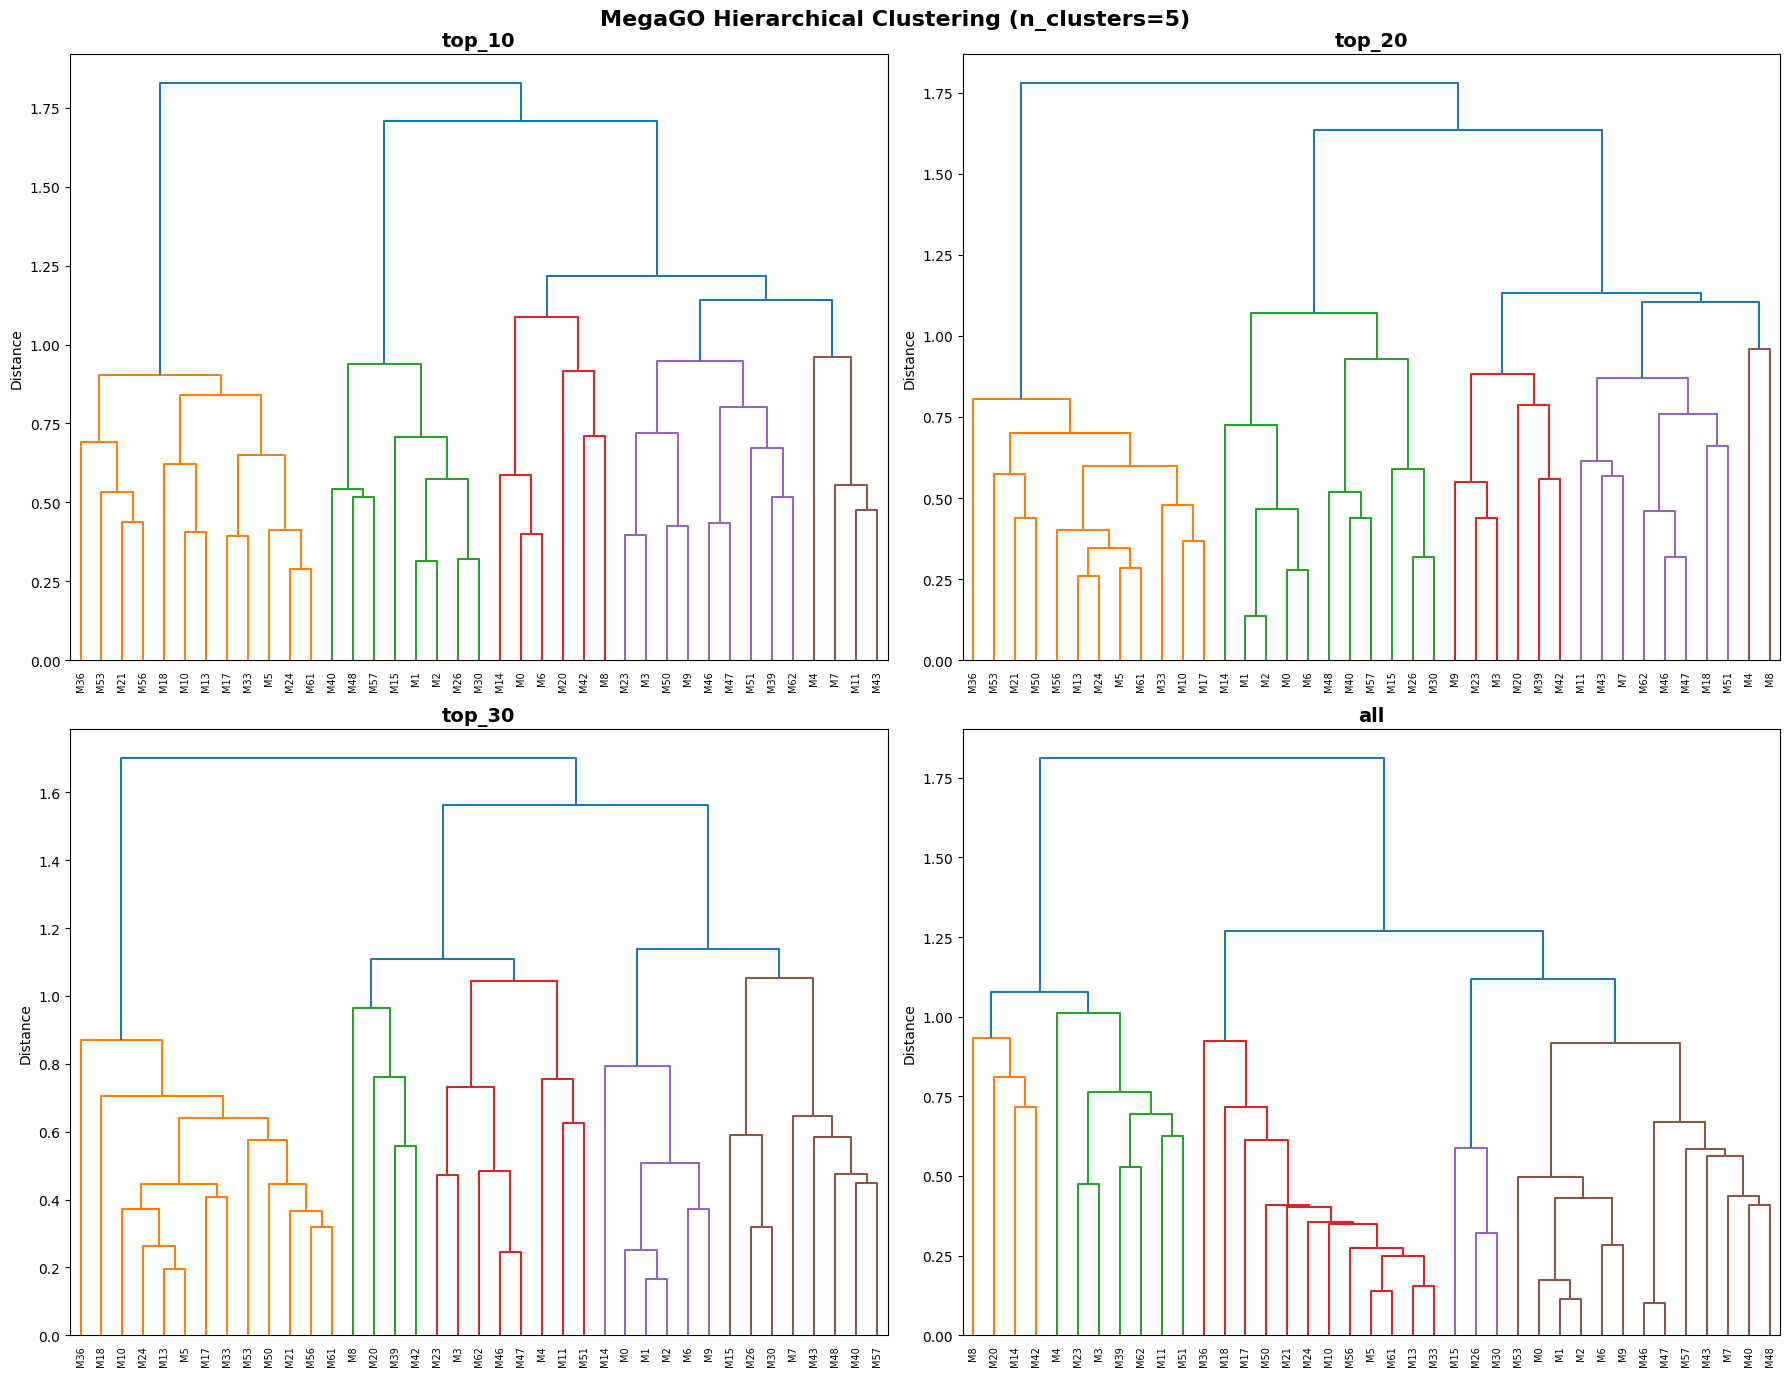


Dendrogram comparison saved.


In [9]:
# Cluster modules for each MegaGO configuration
cluster_assignments = {}  # {config_name: {module_id_str: cluster_label}}
linkage_results = {}

# Number of clusters - can be adjusted
n_clusters = 5

fig, axes = plt.subplots(2, 2, figsize=(18, 14))
axes = axes.flatten()

for idx, (config_name, sim_df) in enumerate(similarity_matrices.items()):
    print(f"\nClustering for: {config_name}")
    
    # Convert similarity to distance
    sim_matrix = sim_df.values
    # Clip to [0, 1] range and convert to distance
    sim_clipped = np.clip(sim_matrix, 0, 1)
    dist_matrix = 1 - sim_clipped
    np.fill_diagonal(dist_matrix, 0)
    
    # Make symmetric (take average of upper/lower triangle)
    dist_matrix = (dist_matrix + dist_matrix.T) / 2
    
    # Hierarchical clustering
    condensed_dist = squareform(dist_matrix, checks=False)
    Z = linkage(condensed_dist, method='ward')
    linkage_results[config_name] = Z
    
    # Cut tree to get cluster assignments
    clusters = fcluster(Z, t=n_clusters, criterion='maxclust')
    
    module_labels = sim_df.index.tolist()
    module_clusters = {}
    for label, cluster in zip(module_labels, clusters):
        module_num = label.replace('Module_', '')
        module_clusters[module_num] = f'Cluster_{cluster}'
    
    cluster_assignments[config_name] = module_clusters
    
    # Print cluster sizes
    from collections import Counter
    cluster_counts = Counter(module_clusters.values())
    for c, count in sorted(cluster_counts.items()):
        print(f"  {c}: {count} modules")
    
    # Plot dendrogram
    ax = axes[idx]
    short_labels = [l.replace('Module_', 'M') for l in module_labels]
    dendrogram(Z, labels=short_labels, ax=ax, leaf_rotation=90, leaf_font_size=7,
               color_threshold=Z[-(n_clusters-1), 2])
    ax.set_title(f'{config_name}', fontsize=14, fontweight='bold')
    ax.set_ylabel('Distance')

plt.suptitle(f'MegaGO Hierarchical Clustering (n_clusters={n_clusters})', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(output_dir, 'dendrograms_comparison.png'), dpi=150, bbox_inches='tight')
plt.show()
print(f"\nDendrogram comparison saved.")

In [10]:
# Compare cluster stability across configurations
print("Cluster assignment comparison across MegaGO configurations:")
print("="*80)

# Build comparison table
all_modules = sorted(set().union(*[set(v.keys()) for v in cluster_assignments.values()]), key=int)
comparison_df = pd.DataFrame(index=all_modules)
for config_name, assignments in cluster_assignments.items():
    comparison_df[config_name] = comparison_df.index.map(lambda m: assignments.get(m, 'N/A'))

print(comparison_df.to_string())
comparison_df.to_csv(os.path.join(output_dir, 'cluster_assignments_comparison.csv'))
print(f"\nSaved to: {os.path.join(output_dir, 'cluster_assignments_comparison.csv')}")

Cluster assignment comparison across MegaGO configurations:
       top_10     top_20     top_30        all
0   Cluster_3  Cluster_2  Cluster_4  Cluster_5
1   Cluster_2  Cluster_2  Cluster_4  Cluster_5
2   Cluster_2  Cluster_2  Cluster_4  Cluster_5
3   Cluster_4  Cluster_3  Cluster_3  Cluster_2
4   Cluster_5  Cluster_5  Cluster_3  Cluster_2
5   Cluster_1  Cluster_1  Cluster_1  Cluster_3
6   Cluster_3  Cluster_2  Cluster_4  Cluster_5
7   Cluster_5  Cluster_4  Cluster_5  Cluster_5
8   Cluster_3  Cluster_5  Cluster_2  Cluster_1
9   Cluster_4  Cluster_3  Cluster_4  Cluster_5
10  Cluster_1  Cluster_1  Cluster_1  Cluster_3
11  Cluster_5  Cluster_4  Cluster_3  Cluster_2
13  Cluster_1  Cluster_1  Cluster_1  Cluster_3
14  Cluster_3  Cluster_2  Cluster_4  Cluster_1
15  Cluster_2  Cluster_2  Cluster_5  Cluster_4
17  Cluster_1  Cluster_1  Cluster_1  Cluster_3
18  Cluster_1  Cluster_4  Cluster_1  Cluster_3
20  Cluster_3  Cluster_3  Cluster_2  Cluster_1
21  Cluster_1  Cluster_1  Cluster_1  Cluster_3


## Step 4: Network Data Preparation

In [11]:
# Network Data Preparation Function
def prepare_network_data():
    """Prepare nodes and edges for the interactive network visualization"""
    nodes = []
    edges = []
    regulator_modules = {'TF': {}, 'metabolite': {}, 'lipid': {}}

    for _, row in module_overview.iterrows():
        module_id = str(row['Module'])
        hover_text = f"<b>Module {module_id}</b><br>"
        
        if 'Expression_p_adjusted' in row and row['Expression_p_adjusted'] != 'NA':
            hover_text += f"<b>Expression Analysis:</b><br>"
            hover_text += f"  \u2022 adj. p-value: {row['Expression_p_adjusted']:.2e}<br>"
            hover_text += f"  \u2022 Rank: {row['Expression_rank']}<br>"
            hover_text += f"  \u2022 Significant: {row['Expression_significant']}<br><br>"
        
        if row['Module_genes'] != 'NA' and pd.notna(row['Module_genes']):
            gene_count = len(row['Module_genes'].split('|'))
            hover_text += f"<b>Genes:</b> {gene_count} genes<br>"

        module_node = {'id': f"Module_{module_id}", 'label': f"M{module_id}", 'type': 'module', 'hover_info': hover_text}
        nodes.append(module_node)

        if 'TF_regulators' in row and pd.notna(row['TF_regulators']) and row['TF_regulators'] != 'NA':
            for tf in [t.strip() for t in str(row['TF_regulators']).split('|') if t.strip()]:
                regulator_modules['TF'].setdefault(tf, []).append(module_id)

        if 'Metabolite_regulators' in row and pd.notna(row['Metabolite_regulators']) and row['Metabolite_regulators'] != 'NA':
            for met in [m.strip() for m in str(row['Metabolite_regulators']).split('|') if m.strip()]:
                regulator_modules['metabolite'].setdefault(met, []).append(module_id)

        if 'Lipid_regulators' in row and pd.notna(row['Lipid_regulators']) and row['Lipid_regulators'] != 'NA':
            for lip in [l.strip() for l in str(row['Lipid_regulators']).split('|') if l.strip()]:
                regulator_modules['lipid'].setdefault(lip, []).append(module_id)

    for reg_type, regulators in regulator_modules.items():
        for regulator, target_modules in regulators.items():
            reg_node = {
                'id': regulator, 'label': regulator, 'type': reg_type,
                'hover_info': f"<b>{reg_type.upper()}:</b> {regulator}<br><b>Targets ({len(target_modules)}):</b> M{', M'.join(target_modules)}"
            }
            nodes.append(reg_node)
            for m in target_modules:
                edges.append({'source': regulator, 'target': f"Module_{m}", 'type': f"{reg_type}_to_module"})

    print(f"Network data prepared: {len(nodes)} nodes, {len(edges)} edges")
    return nodes, edges, regulator_modules

print("Network data preparation function defined!")

Network data preparation function defined!


In [12]:
# Regulator Filtering Function with Score-based Selection
def filter_top_regulators(nodes, edges, regulator_scores, min_targets=3, max_regulators_per_type=20,
                          min_score=None, top_pairs_by_score=5):
    """Filter regulators based on connectivity and also include top regulator-module pairs by score."""
    node_types = {n['id']: n['type'] for n in nodes}
    regulator_targets = {}
    regulator_avg_scores = {}
    all_scored_pairs = []
    
    for edge in edges:
        source = edge['source']
        if source in node_types and node_types[source] in ['TF', 'metabolite', 'lipid']:
            if source not in regulator_targets:
                regulator_targets[source] = []
            target_module = edge['target'].replace('Module_', '')
            regulator_targets[source].append(target_module)
            
            reg_type = node_types[source]
            score_dict = regulator_scores.get(reg_type, {})
            pair_score = score_dict.get((source, target_module), 0)
            all_scored_pairs.append({
                'regulator': source, 'module': target_module, 'target': edge['target'],
                'score': pair_score, 'type': reg_type
            })
            
            scores = [score_dict.get((source, mod), 0) for mod in regulator_targets[source]]
            regulator_avg_scores[source] = sum(scores) / len(scores) if scores else 0
    
    regulators_by_type = {'TF': [], 'metabolite': [], 'lipid': []}
    for reg_id, target_list in regulator_targets.items():
        count = len(target_list)
        avg_score = regulator_avg_scores.get(reg_id, 0)
        if count >= min_targets:
            if min_score is None or avg_score >= min_score:
                reg_type = node_types[reg_id]
                regulators_by_type[reg_type].append((reg_id, count, avg_score))
    
    selected_regulators = set()
    connectivity_edges = []
    
    for reg_type, regs in regulators_by_type.items():
        sorted_regs = sorted(regs, key=lambda x: (x[1], x[2]), reverse=True)
        if len(sorted_regs) <= max_regulators_per_type:
            selected_regulators.update([r[0] for r in sorted_regs])
        else:
            cutoff_count = sorted_regs[max_regulators_per_type - 1][1]
            top_regs = [r for r in sorted_regs if r[1] >= cutoff_count]
            selected_regulators.update([r[0] for r in top_regs[:max_regulators_per_type]])
    
    for edge in edges:
        if edge['source'] in selected_regulators or edge['source'].startswith('Module_'):
            connectivity_edges.append(edge)
    
    scored_pairs_by_type = {'TF': [], 'metabolite': [], 'lipid': []}
    for pair in all_scored_pairs:
        scored_pairs_by_type[pair['type']].append(pair)
    
    top_scoring_pairs = []
    for reg_type in ['TF', 'metabolite', 'lipid']:
        sorted_pairs = sorted(scored_pairs_by_type[reg_type], key=lambda x: x['score'], reverse=True)
        top_scoring_pairs.extend(sorted_pairs[:top_pairs_by_score])
    
    score_based_edges = []
    for pair in top_scoring_pairs:
        selected_regulators.add(pair['regulator'])
        edge_obj = {'source': pair['regulator'], 'target': pair['target'], 'type': f"{pair['type']}_to_module"}
        if edge_obj not in connectivity_edges and edge_obj not in score_based_edges:
            score_based_edges.append(edge_obj)
    
    all_filtered_edges = connectivity_edges + score_based_edges
    filtered_nodes = [n for n in nodes if n['type'] == 'module' or n['id'] in selected_regulators]
    
    regulators_by_type_with_scores = {}
    for reg_type, regs in regulators_by_type.items():
        regulators_by_type_with_scores[reg_type] = [(r[0], r[1], r[2]) for r in regs]
    
    return filtered_nodes, all_filtered_edges, regulators_by_type_with_scores, top_scoring_pairs

print("Regulator filtering function defined!")

Regulator filtering function defined!


In [13]:
# Prepare network data and filter regulators (shared across all configs)
print("Preparing network data...")
nodes, edges, regulator_modules = prepare_network_data()

# annotate edges with interaction category based on PKN
edges = annotate_edges_with_category(edges)
from collections import Counter
print("Edge categories distribution:", Counter([e.get('category','Other') for e in edges]))

# keep a copy of the unfiltered network so we can also generate a full view
full_nodes, full_edges = nodes, edges

print("\nFiltering regulators...")
filtered_nodes, filtered_edges, regulator_stats, top_pairs = filter_top_regulators(
    nodes, edges, regulator_scores,
    min_targets=3, max_regulators_per_type=10,
    min_score=None, top_pairs_by_score=5
)
print(f"Filtered: {len(filtered_nodes)} nodes, {len(filtered_edges)} edges")

# dictionary of network variants we will use later
network_variants = {
    'filtered': (filtered_nodes, filtered_edges),
    'full': (full_nodes, full_edges)
}

Preparing network data...
Network data prepared: 349 nodes, 596 edges
Edge categories distribution: Counter({'Other': 564, 'Metabolic_pathway': 32})

Filtering regulators...
Filtered: 74 nodes, 192 edges


## Step 5: visualization in python html network

This section will create **two versions** of the module‑regulator network for each MegaGO configuration:
- a **filtered** network that retains only top regulators (as before)
- a **full** network with no selection, i.e. every node and edge generated from the data

Both variants are written out with distinct filenames and exported to Cytoscape later.

In [14]:
# Interactive HTML Network Visualization (Plotly) - colored by MegaGO cluster
import plotly.graph_objects as go


def create_megago_cluster_layout(nodes, edges, module_clusters):
    """Create layout where modules are positioned based on their MegaGO cluster."""
    clusters = list(set(module_clusters.values()))
    n_clusters_layout = len(clusters)
    
    cluster_positions = {}
    for i, cl in enumerate(clusters):
        angle = 2 * np.pi * i / n_clusters_layout
        radius = 8
        cluster_positions[cl] = (radius * np.cos(angle), radius * np.sin(angle))
    
    pos = {}
    modules_by_cluster = {cl: [] for cl in clusters}
    for node in nodes:
        if node['type'] == 'module':
            module_id = node['id'].replace('Module_', '')
            cl = module_clusters.get(module_id, 'Unassigned')
            if cl not in modules_by_cluster:
                modules_by_cluster[cl] = []
            modules_by_cluster[cl].append(node['id'])
    
    np.random.seed(42)
    for cl, module_ids in modules_by_cluster.items():
        if cl not in cluster_positions:
            cluster_positions[cl] = (0, 0)
        center_x, center_y = cluster_positions[cl]
        n_modules = len(module_ids)
        
        if n_modules == 1:
            pos[module_ids[0]] = (center_x, center_y)
        else:
            for i, mod_id in enumerate(module_ids):
                angle = 2 * np.pi * i / n_modules
                jitter_radius = min(2.5, 0.5 + 0.3 * n_modules)
                x = center_x + jitter_radius * np.cos(angle)
                y = center_y + jitter_radius * np.sin(angle)
                pos[mod_id] = (x, y)
    
    # Position regulator nodes near their targets
    for node in nodes:
        if node['id'] not in pos:
            connected_modules = [e['target'] for e in edges if e['source'] == node['id']]
            if connected_modules:
                # determine cluster membership of targets
                connected_clusters = set(
                    module_clusters.get(m.replace('Module_', ''), 'Unassigned')
                    for m in connected_modules
                )
                connected_pos = [pos[m] for m in connected_modules if m in pos]
                if connected_pos:
                    if len(connected_clusters) == 1:
                        # if all targets in single cluster, start at cluster center
                        center_x, center_y = cluster_positions[next(iter(connected_clusters))]
                    else:
                        # otherwise average the module positions
                        center_x = np.mean([p[0] for p in connected_pos])
                        center_y = np.mean([p[1] for p in connected_pos])
                    offset_dist = 1.5
                    if node['type'] == 'TF':
                        angle_offset = 0
                    elif node['type'] == 'metabolite':
                        angle_offset = 2 * np.pi / 3
                    else:
                        angle_offset = 4 * np.pi / 3
                    offset_x = offset_dist * np.cos(angle_offset + np.random.normal(0, 0.5))
                    offset_y = offset_dist * np.sin(angle_offset + np.random.normal(0, 0.5))
                    pos[node['id']] = (center_x + offset_x, center_y + offset_y)
                else:
                    pos[node['id']] = (0, 0)
            else:
                pos[node['id']] = (0, 0)
    
    return pos, cluster_positions


def build_enriched_hover_text(module_id, module_overview, module_enrichment_all, edges):
    """Build rich hover text for a module node including expression, regulators, and enrichment info."""
    hover_text = f"<b>Module {module_id}</b><br>"
    row = module_overview[module_overview['Module'].astype(str) == str(module_id)]
    if len(row) > 0:
        row = row.iloc[0]
        # Expression analysis
        if 'Expression_p_adjusted' in row.index and row['Expression_p_adjusted'] != 'NA':
            try:
                hover_text += f"<b>Expression Analysis:</b><br>"
                hover_text += f"  \u2022 adj. p-value: {float(row['Expression_p_adjusted']):.2e}<br>"
                hover_text += f"  \u2022 Rank: {row['Expression_rank']}<br>"
                hover_text += f"  \u2022 Significant: {row['Expression_significant']}<br><br>"
            except (ValueError, TypeError):
                pass
        # Gene count
        if 'Module_genes' in row.index and row['Module_genes'] != 'NA' and pd.notna(row['Module_genes']):
            gene_count = len(str(row['Module_genes']).split('|'))
            hover_text += f"<b>Genes:</b> {gene_count} genes<br><br>"
    # Regulators per type
    module_target = f"Module_{module_id}"
    reg_type_labels = {'TF': 'Transcription Factors', 'metabolite': 'Metabolites', 'lipid': 'Lipids'}
    for reg_type, reg_label in reg_type_labels.items():
        regs = sorted(set(e['source'] for e in edges if e['target'] == module_target and e['type'] == f"{reg_type}_to_module"))
        if regs:
            hover_text += f"<b>{reg_label} ({len(regs)}):</b> "
            hover_text += ', '.join(regs[:10])
            if len(regs) > 10:
                hover_text += f", ... (+{len(regs)-10} more)"
            hover_text += '<br>'
    hover_text += '<br>'
    # Top enriched pathways from ALL databases (BP, MF, CC, KEGG, Reactome)
    if module_enrichment_all is not None and not module_enrichment_all.empty:
        mod_enrich = module_enrichment_all[module_enrichment_all['Module'].astype(str) == str(module_id)]
        for db in ['BP', 'MF', 'CC', 'KEGG', 'Reactome']:
            db_enrich = mod_enrich[mod_enrich['Database'] == db].sort_values('p.adjust').head(3)
            if len(db_enrich) > 0:
                hover_text += f"<b>Top {db}:</b><br>"
                for _, erow in db_enrich.iterrows():
                    term = str(erow['Term'])
                    if len(term) > 55:
                        term = term[:52] + '...'
                    p_val = erow['p.adjust']
                    hover_text += f"  \u2022 {term} (p={p_val:.1e})<br>"
    return hover_text


def create_megago_interactive_network(nodes, edges, module_clusters, config_name,
                                      module_overview, module_enrichment_all, movable=False):
    """Create interactive Plotly network with modules colored by MegaGO cluster.

    If ``movable`` is True each node is placed in its own scatter trace so the
    resulting HTML (with ``config={'editable': True}``) lets you click‑and‑drag
    individual points to avoid overlaps.
    """
    # build enriched hover info & optionally split into per-node traces later
    enriched_nodes = []
    for node in nodes:
        enriched_node = dict(node)
        if node['type'] == 'module':
            module_id = node['id'].replace('Module_', '')
            enriched_node['hover_info'] = build_enriched_hover_text(
                module_id, module_overview, module_enrichment_all, edges
            )
            # Add cluster info to hover
            cluster = module_clusters.get(module_id, 'Unassigned')
            enriched_node['hover_info'] += f"<br><b>MegaGO Cluster:</b> {cluster}"
        enriched_nodes.append(enriched_node)
    # create layout positions
    pos, cluster_positions = create_megago_cluster_layout(enriched_nodes, edges, module_clusters)

    # color palette
    all_clusters = sorted(set(module_clusters.values()))
    cluster_palette = ['#EE6677', '#4477AA', '#228833', '#AA3377', '#66CCEE',
                       '#CCBB44', '#EE99AA', '#44BB99', '#BBCC33', '#AAAA00']
    cluster_color_map = {cl: cluster_palette[i % len(cluster_palette)] for i, cl in enumerate(all_clusters)}
    cluster_color_map['Unassigned'] = '#BBBBBB'
    regulator_color = '#FF8C00'

    # prepare edge traces by interaction category (Causal, Metabolic_pathway, Other)
    edge_styles = {
        'Causal': {'color': 'rgba(80,80,80,0.9)', 'width': 3.0, 'label': 'Causal'},
        'Metabolic_pathway': {'color': 'rgba(80,80,80,0.85)', 'width': 2.5, 'label': 'Metabolic pathway'},
        'Other': {'color': 'rgba(80,80,80,0.6)', 'width': 1.5, 'label': 'Other'}
    }
    edge_traces = {}
    for cat, style in edge_styles.items():
        edge_traces[cat] = go.Scatter(x=[], y=[],
                                      line=dict(width=style['width'], color=style['color']),
                                      hoverinfo='none', mode='lines',
                                      name=style['label'], showlegend=True)

    # accumulate coordinates into appropriate category traces
    # use temporary dicts because Scatter.x/y always return tuples
    temp_coords = {cat: {'x': [], 'y': []} for cat in edge_traces}
    for edge in edges:
        if edge['source'] in pos and edge['target'] in pos:
            x0, y0 = pos[edge['source']]
            x1, y1 = pos[edge['target']]
            cat = edge.get('category', 'Other')
            if cat not in temp_coords:
                cat = 'Other'
            temp_coords[cat]['x'].extend([x0, x1, None])
            temp_coords[cat]['y'].extend([y0, y1, None])

    # assign the accumulated lists back to the traces
    for cat, coords in temp_coords.items():
        edge_traces[cat].x = coords['x']
        edge_traces[cat].y = coords['y']

    # build figure with edge traces (draw Other first so thicker edges overlay)
    fig = go.Figure()
    for cat in ['Other', 'Metabolic_pathway', 'Causal']:
        fig.add_trace(edge_traces[cat])

    # ------------------------------------------------------------------
    # decorate the end of some edges
    # ------------------------------------------------------------------
    for edge in edges:
        if edge['source'] in pos and edge['target'] in pos:
            x0, y0 = pos[edge['source']]
            x1, y1 = pos[edge['target']]
            cat = edge.get('category', 'Other')
            if cat == 'Causal':
                # arrowhead pointing at the target
                fig.add_annotation(
                    x=x1, y=y1, ax=x0, ay=y0,
                    xref='x', yref='y', axref='x', ayref='y',
                    showarrow=True, arrowhead=3, arrowsize=1,
                    arrowwidth=edge_styles[cat]['width'],
                    arrowcolor=edge_styles[cat]['color'],
                    opacity=0.8
                )
            elif cat == 'Metabolic_pathway':
                # tiny dot at the target end
                fig.add_trace(go.Scatter(
                    x=[x1], y=[y1], mode='markers',
                    marker=dict(symbol='circle', size=6,
                                color=edge_styles[cat]['color'], line=dict(width=0)),
                    hoverinfo='none', showlegend=False
                ))

    if movable:
        # one trace per node to allow individual dragging
        for n in enriched_nodes:
            x = pos.get(n['id'], (0,0))[0]
            y = pos.get(n['id'], (0,0))[1]
            label = n.get('label', n['id'])
            txt = label if n['type']=='module' else label[:15]
            symbol = 'circle' if n['type']=='module' else 'diamond-wide'
            color = cluster_color_map.get(module_clusters.get(n['id'].replace('Module_',''), ''), '#BBBBBB') if n['type']=='module' else regulator_color
            size = 50 if n['type']=='module' else min(80, max(25, len(txt)*4))
            fig.add_trace(go.Scatter(x=[x], y=[y], mode='markers+text',
                                     marker=dict(size=size, color=color,
                                                 line=dict(width=2 if n['type']=='module' else 1, color='white' if n['type']=='module' else 'darkorange'),
                                                 symbol=symbol),
                                     text=[txt], textposition='middle center',
                                     textfont=dict(size=12 if n['type']=='module' else 8, color='black', family='Arial Black'),
                                     hovertext=[n.get('hover_info', txt)], hoverinfo='text',
                                     name=n['id'], showlegend=False))
    else:
        # grouped module traces by cluster
        module_traces = []
        for cluster in all_clusters:
            cat_nodes = [n for n in enriched_nodes if n['type']=='module' and
                         module_clusters.get(n['id'].replace('Module_',''),'Unassigned')==cluster]
            if not cat_nodes:
                continue
            x_vals = [pos[n['id']][0] for n in cat_nodes]
            y_vals = [pos[n['id']][1] for n in cat_nodes]
            hover_texts = [n.get('hover_info', n['label']) for n in cat_nodes]
            labels = [n['id'].replace('Module_','') for n in cat_nodes]
            trace = go.Scatter(x=x_vals, y=y_vals, mode='markers+text',
                              marker=dict(size=50, color=cluster_color_map.get(cluster,'#CCCCCC'),
                                          line=dict(width=2, color='white'), symbol='circle'),
                              text=labels, textposition='middle center',
                              textfont=dict(size=12, color='black', family='Arial Black'),
                              hovertext=hover_texts, hoverinfo='text',
                              name=f"{cluster} ({len(cat_nodes)})", legendgroup=cluster)
            module_traces.append(trace)
        for tr in module_traces:
            fig.add_trace(tr)
        # unassigned
        unassigned_nodes = [n for n in enriched_nodes if n['type']=='module' and
                            module_clusters.get(n['id'].replace('Module_',''),'Unassigned')=='Unassigned']
        if unassigned_nodes:
            x_vals = [pos[n['id']][0] for n in unassigned_nodes]
            y_vals = [pos[n['id']][1] for n in unassigned_nodes]
            hover_texts = [n.get('hover_info', n['label']) for n in unassigned_nodes]
            labels = [n['id'].replace('Module_','') for n in unassigned_nodes]
            trace = go.Scatter(x=x_vals, y=y_vals, mode='markers+text',
                              marker=dict(size=50, color='#BBBBBB',
                                          line=dict(width=2, color='white'), symbol='circle'),
                              text=labels, textposition='middle center',
                              textfont=dict(size=12, color='black', family='Arial Black'),
                              hovertext=hover_texts, hoverinfo='text',
                              name=f'Unassigned ({len(unassigned_nodes)})', legendgroup='Unassigned')
            fig.add_trace(trace)
        # regulator traces grouped by type
        regulator_traces = []
        for reg_type in ['TF','metabolite','lipid']:
            reg_nodes = [n for n in enriched_nodes if n['type']==reg_type]
            if not reg_nodes:
                continue
            x_vals = [pos[n['id']][0] for n in reg_nodes]
            y_vals = [pos[n['id']][1] for n in reg_nodes]
            hover_texts = [n.get('hover_info', n['label']) for n in reg_nodes]
            labels = [n['label'][:15] if len(n['label'])>15 else n['label'] for n in reg_nodes]
            sizes = [min(80, max(25, len(label)*4)) for label in labels]
            trace = go.Scatter(x=x_vals, y=y_vals, mode='markers+text',
                              marker=dict(size=sizes, color=regulator_color, symbol='diamond-wide',
                                          line=dict(width=1, color='darkorange')),
                              text=labels, textposition='middle center',
                              textfont=dict(size=8, color='black'),
                              hovertext=hover_texts, hoverinfo='text',
                              name=f"{reg_type.capitalize()} ({len(reg_nodes)})", legendgroup=f'reg_{reg_type}')
            regulator_traces.append(trace)
        for tr in regulator_traces:
            fig.add_trace(tr)
    # annotations for clusters
    annotations = []
    for cl, (x, y) in cluster_positions.items():
        annotations.append(dict(x=x*1.3, y=y*1.3, text=f'<b>{cl}</b>', showarrow=False,
                               font=dict(size=14, color=cluster_color_map.get(cl,'#000000')),
                               bgcolor='rgba(255,255,255,0.8)', borderpad=4))
    fig.update_layout(
        title=dict(text=f'Module-Regulator Network<br><sub>Modules colored by MegaGO cluster ({config_name})</sub>',
                   x=0.5, font=dict(size=20)),
        showlegend=True, hovermode='closest', width=1400, height=1000,
        xaxis=dict(showgrid=False, zeroline=False, showticklabels=False),
        yaxis=dict(showgrid=False, zeroline=False, showticklabels=False),
        plot_bgcolor='white', annotations=annotations,
        legend=dict(x=1.02, y=1, bgcolor='rgba(255,255,255,0.9)',
                    bordercolor='black', borderwidth=1, font=dict(size=10))
    )
    # for editable figures we don't need a special dragmode – configuration
    # passed to write_html (editable=True) already allows dragging individual
    # points.  Setting an unsupported value caused a ValueError earlier.
    return fig

# Generate interactive HTML networks for each MegaGO configuration
print("=" * 60)
print("INTERACTIVE HTML NETWORK VISUALIZATION (MegaGO clusters)")
print("=" * 60)

# iterate over variants (filtered vs full) so we can produce both versions
for variant_name, (nodes_to_use, edges_to_use) in network_variants.items():
    for config_name, module_clusters in cluster_assignments.items():
        print(f"Generating {variant_name} network for: {config_name}")
        fig = create_megago_interactive_network(
            nodes_to_use, edges_to_use, module_clusters, config_name,
            module_overview, module_enrichment_all
        )
        html_path = os.path.join(output_dir, f'module_network_{variant_name}_megaGO_{config_name}.html')
        fig.write_html(html_path)
        print(f"  Saved: {html_path}")
        try:
            png_path = os.path.join(output_dir, f'module_network_{variant_name}_megaGO_{config_name}.png')
            fig.write_image(png_path, width=1400, height=1000, scale=2)
            print(f"  Saved: {png_path}")
        except Exception as e:
            print(f"  Note: Could not export PNG: {e}")
        fig.show()

        mov_fig = create_megago_interactive_network(
            nodes_to_use, edges_to_use, module_clusters, config_name,
            module_overview, module_enrichment_all, movable=True
        )
        mov_html = os.path.join(output_dir, f'module_network_{variant_name}_megaGO_{config_name}_movable.html')
        mov_fig.write_html(mov_html, config={'editable': True})
        print(f"  Saved movable version: {mov_html}")

print(f"All interactive HTML networks saved to: {output_dir}")


INTERACTIVE HTML NETWORK VISUALIZATION (MegaGO clusters)
Generating filtered network for: top_10
  Saved: ./Networks/megaGO_exploration/module_network_filtered_megaGO_top_10.html
  Saved: ./Networks/megaGO_exploration/module_network_filtered_megaGO_top_10.png


  Saved movable version: ./Networks/megaGO_exploration/module_network_filtered_megaGO_top_10_movable.html
Generating filtered network for: top_20
  Saved: ./Networks/megaGO_exploration/module_network_filtered_megaGO_top_20.html
  Saved: ./Networks/megaGO_exploration/module_network_filtered_megaGO_top_20.png


  Saved movable version: ./Networks/megaGO_exploration/module_network_filtered_megaGO_top_20_movable.html
Generating filtered network for: top_30
  Saved: ./Networks/megaGO_exploration/module_network_filtered_megaGO_top_30.html
  Saved: ./Networks/megaGO_exploration/module_network_filtered_megaGO_top_30.png


  Saved movable version: ./Networks/megaGO_exploration/module_network_filtered_megaGO_top_30_movable.html
Generating filtered network for: all
  Saved: ./Networks/megaGO_exploration/module_network_filtered_megaGO_all.html
  Saved: ./Networks/megaGO_exploration/module_network_filtered_megaGO_all.png


  Saved movable version: ./Networks/megaGO_exploration/module_network_filtered_megaGO_all_movable.html
Generating full network for: top_10
  Saved: ./Networks/megaGO_exploration/module_network_full_megaGO_top_10.html
  Saved: ./Networks/megaGO_exploration/module_network_full_megaGO_top_10.png


  Saved movable version: ./Networks/megaGO_exploration/module_network_full_megaGO_top_10_movable.html
Generating full network for: top_20
  Saved: ./Networks/megaGO_exploration/module_network_full_megaGO_top_20.html
  Saved: ./Networks/megaGO_exploration/module_network_full_megaGO_top_20.png


  Saved movable version: ./Networks/megaGO_exploration/module_network_full_megaGO_top_20_movable.html
Generating full network for: top_30
  Saved: ./Networks/megaGO_exploration/module_network_full_megaGO_top_30.html
  Saved: ./Networks/megaGO_exploration/module_network_full_megaGO_top_30.png


  Saved movable version: ./Networks/megaGO_exploration/module_network_full_megaGO_top_30_movable.html
Generating full network for: all
  Saved: ./Networks/megaGO_exploration/module_network_full_megaGO_all.html
  Saved: ./Networks/megaGO_exploration/module_network_full_megaGO_all.png


  Saved movable version: ./Networks/megaGO_exploration/module_network_full_megaGO_all_movable.html
All interactive HTML networks saved to: ./Networks/megaGO_exploration


## Step 6: Cytoscape Visualization for Each MegaGO Configuration

Create a Cytoscape network for each configuration, with modules colored by MegaGO cluster.

In [15]:
# Export Cytoscape-compatible files for each configuration and variant
for config_name, module_clusters in cluster_assignments.items():
    for variant_name, (nodes_to_use, edges_to_use) in network_variants.items():
        print(f"\nExporting Cytoscape files for: {config_name} ({variant_name})")
        
        config_output = os.path.join(output_dir, config_name, variant_name)
        os.makedirs(config_output, exist_ok=True)
        
        cytoscape_sif = os.path.join(config_output, 'module_network_edges.txt')
        cytoscape_node_attr = os.path.join(config_output, 'module_network_node_attributes.txt')
        # cytoscape_edge_attr = os.path.join(config_output, 'module_network_edge_attributes.txt')
        
        # combined edge list + attributes
        with open(cytoscape_sif, 'w') as f:
            f.write("source\ttarget\tCategory\tArrowShape\n")
            for edge in edges_to_use:
                cat = edge.get('category', 'Other')
                if cat == 'Causal':
                    arrow = 'DELTA'
                elif cat == 'Metabolic_pathway':
                    arrow = 'DOT'
                else:
                    arrow = ''
                f.write(f"{edge['source']}\t{edge['target']}\t{cat}\t{arrow}\n")
        
        # node attributes (add expression/PPI/gene-count for modules)
        with open(cytoscape_node_attr, 'w') as f:
            f.write("Node\tMegaGO_Cluster\tNode_Type\tExpression_significant\tPPI_significant\tModule_genes_count\n")
            for node in nodes_to_use:
                node_id = node['id']
                node_type = node['type']
                if node_type == 'module':
                    module_num = node_id.replace('Module_', '')
                    cluster = module_clusters.get(module_num, 'Unassigned')
                    # look up extra info in module_overview
                    row = module_overview[module_overview['Module'].astype(str) == module_num]
                    expr_flag = ''
                    ppi_flag = ''
                    gene_count = ''
                    if len(row) > 0:
                        try:
                            expr_flag = 'Yes' if row.iloc[0].get('Expression_significant', '') == 'Yes' else 'No'
                        except Exception:
                            expr_flag = ''
                        try:
                            ppi_val = row.iloc[0].get('PPI_FDR', np.nan)
                            ppi_flag = 'Yes' if pd.notna(ppi_val) and ppi_val < 0.05 else 'No'
                        except Exception:
                            ppi_flag = ''
                        try:
                            genes = row.iloc[0].get('Module_genes', '')
                            gene_count = len(str(genes).split('|')) if pd.notna(genes) and genes != 'NA' else 0
                        except Exception:
                            gene_count = ''
                    f.write(f"{node_id}\t{cluster}\t{node_type}\t{expr_flag}\t{ppi_flag}\t{gene_count}\n")
                else:
                    # regulators: leave new columns empty
                    f.write(f"{node_id}\t\t{node_type}\t\t\t\n")
        
        print(f"  Saved edge list + attributes: {cytoscape_sif}")
        print(f"  Saved node attrs: {cytoscape_node_attr}")

print("\nAll Cytoscape files exported.")



Exporting Cytoscape files for: top_10 (filtered)
  Saved edge list + attributes: ./Networks/megaGO_exploration/top_10/filtered/module_network_edges.txt
  Saved node attrs: ./Networks/megaGO_exploration/top_10/filtered/module_network_node_attributes.txt

Exporting Cytoscape files for: top_10 (full)
  Saved edge list + attributes: ./Networks/megaGO_exploration/top_10/full/module_network_edges.txt
  Saved node attrs: ./Networks/megaGO_exploration/top_10/full/module_network_node_attributes.txt

Exporting Cytoscape files for: top_20 (filtered)
  Saved edge list + attributes: ./Networks/megaGO_exploration/top_20/filtered/module_network_edges.txt
  Saved node attrs: ./Networks/megaGO_exploration/top_20/filtered/module_network_node_attributes.txt

Exporting Cytoscape files for: top_20 (full)
  Saved edge list + attributes: ./Networks/megaGO_exploration/top_20/full/module_network_edges.txt
  Saved node attrs: ./Networks/megaGO_exploration/top_20/full/module_network_node_attributes.txt

Exporti

## Cytoscape Network Visualization

**Requirements:** Cytoscape must be running on your machine before executing these cells.

Creates one network per MegaGO configuration, all with the same visual style.

In [ ]:
# Create Cytoscape networks for all configurations (filtered and full)
from py4cytoscape import *
from py4cytoscape.style_bypasses import (set_node_shape_bypass, set_node_width_bypass,
                                          set_node_height_bypass, set_node_font_size_bypass)
import pandas as pd

# Color-blind friendly palette for clusters (Paul Tol's bright scheme)
cluster_color_map = {
    'Cluster_1': '#4477AA',  # Blue
    'Cluster_2': '#EE6677',  # Rose
    'Cluster_3': '#228833',  # Green
    'Cluster_4': '#CCBB44',  # Yellow
    'Cluster_5': '#66CCEE',  # Cyan
    'Cluster_6': '#AA3377',  # Purple
    'Cluster_7': '#EE99AA',  # Light Pink
    'Cluster_8': '#BBBBBB',  # Gray
    'Unassigned': '#DDDDDD'
}

network_suids = {}

for config_name in megago_configs.keys():
    for variant_name in network_variants.keys():
        print(f"\n{'='*60}")
        print(f"Creating Cytoscape network: {config_name} ({variant_name})")
        print(f"{'='*60}")
        
        config_output = os.path.join(output_dir, config_name, variant_name)
        cytoscape_sif = os.path.join(config_output, 'module_network_cytoscape.txt')
        cytoscape_attr = os.path.join(config_output, 'module_network_attributes.txt')
        
        network_name = f'MegaGO_{config_name}_{variant_name}'
        
        # Delete existing network if it exists
        try:
            existing_networks = get_network_list()
            if network_name in existing_networks:
                network_suid_to_delete = get_network_suid(network_name)
                delete_network(network=network_suid_to_delete)
                print(f"  Deleted existing network: {network_name}")
        except:
            pass
        
        # Read network files
        edges_df = pd.read_csv(cytoscape_sif, sep='\t')
        edges_df.columns = ['source', 'target']
        nodes_df = pd.read_csv(cytoscape_attr, sep='\t')
        nodes_df.rename(columns={'Node': 'id', 'MegaGO_Cluster': 'color_key', 'Node_Type': 'type'}, inplace=True)
        
        # Create network
        network_suid = create_network_from_data_frames(
            nodes=nodes_df, edges=edges_df, title=network_name, collection='MegaGO_Exploration'
        )
        network_suids[f"{config_name}_{variant_name}"] = network_suid
        
        node_table = get_table_columns(table='node', network=network_suid)
        edge_table = get_table_columns(table='edge', network=network_suid)
        print(f"  Network created - Nodes: {len(node_table)}, Edges: {len(edge_table)}")

print(f"\nAll {len(network_suids)} networks created in Cytoscape.")

DEBUG	py4...:py4cytoscape_logger.py:log_incoming()- Calling get_network_list()
DEBUG	py4...:py4cytoscape_logger.py:log_incoming()- ǀCalling cyrest_get('networks.names', base_url='http://127.0.0.1:1234/v1')
DEBUG	py4...:py4cytoscape_notebook.py:check_execution_environment()- Attempting to direct connect to Cytoscape on http://127.0.0.1:1234/v1
DEBUG	py4...:py4cytoscape_notebook.py:check_execution_environment()- Attempting to connect to remote Cytoscape because of error HTTPConnectionPool(host='127.0.0.1', port=1234): Max retries exceeded with url: /v1 (Caused by NewConnectionError('<urllib3.connection.HTTPConnection object at 0x7fca6ee774d0>: Failed to establish a new connection: [Errno 111] Connection refused'))
DEBUG	py4...:py4cytoscape_logger.py:log_http_request()- ǀHTTP GET(http://127.0.0.1:1234/v1)



Creating Cytoscape network: top_10


DEBUG	py4...:py4cytoscape_notebook.py:check_execution_environment()- Error initially contacting Jupyter-bridge: Error posting to Jupyter-bridge: Channel None:request contains unprocessed message
In cyrest_get: Cannot find local or remote Cytoscape. Start Cytoscape and then proceed.
DEBUG	py4...:py4cytoscape_logger.py:log_exception()- ǀ'cyrest_get' exception RequestException('Cannot find local or remote Cytoscape. Start Cytoscape and then proceed.')
DEBUG	py4...:py4cytoscape_logger.py:log_exception()- 'get_network_list' exception RequestException('Cannot find local or remote Cytoscape. Start Cytoscape and then proceed.')
DEBUG	py4...:py4cytoscape_logger.py:log_finally()- --------------------


ValueError: Length mismatch: Expected axis has 3 elements, new values have 2 elements

In [ ]:
# Apply Visual Style to all networks
style_name = 'MegaGO_Cluster_Style'

if style_name in get_visual_style_names():
    delete_visual_style(style_name)
create_visual_style(style_name)

# Set defaults
set_node_shape_default('ELLIPSE', style_name=style_name)
set_node_size_default(50, style_name=style_name)
set_node_font_size_default(14, style_name=style_name)
set_edge_line_width_default(1.5, style_name=style_name)
set_edge_target_arrow_shape_default('NONE', style_name=style_name)

# map edge widths by interaction category (Causal thicker, metabolic medium, other thin)
try:
    set_edge_line_width_mapping(
        table_column='Category',
        table_column_values=['Other','Metabolic_pathway','Causal'],
        widths=[1.5, 2.5, 3.0],
        mapping_type='discrete',
        style_name=style_name
    )
    # optional arrow mapping: causal edges get an arrowhead
    set_edge_target_arrow_shape_mapping(
        table_column='Category',
        table_column_values=['Other','Metabolic_pathway','Causal'],
        arrow_shapes=['NONE','NONE','DELTA'],
        mapping_type='discrete',
        style_name=style_name
    )
except Exception:
    # mapping function may not exist in older py4cytoscape versions
    pass

# Map node colors by MegaGO cluster
set_node_color_mapping(
    table_column='color_key',
    table_column_values=list(cluster_color_map.keys()),
    colors=list(cluster_color_map.values()),
    mapping_type='discrete',
    style_name=style_name
)
set_node_label_mapping(table_column='name', style_name=style_name)

print(f"Visual style '{style_name}' created.")

# Apply style and bypasses to each network
for config_name, network_suid in network_suids.items():
    print(f"\nApplying style to: {config_name}")
    set_visual_style(style_name, network=network_suid)
    
    node_table = get_table_columns(table='node', network=network_suid)
    
    # Module labels: show just the number
    module_nodes = node_table[node_table['type'] == 'module']
    for node_name in module_nodes['name']:
        label = node_name.replace('Module_', '')
        set_node_label_bypass(node_names=[node_name], new_labels=[label], network=network_suid)
    
    # Read edges for degree calculation
    config_output = os.path.join(output_dir, config_name)
    edges_df = pd.read_csv(os.path.join(config_output, 'module_network_cytoscape.txt'), sep='\t')
    edges_df.columns = ['source', 'target']
    
    # Regulator nodes: RECTANGLE shape, dynamic width, orange gradient
    regulator_nodes = node_table[node_table['type'] != 'module']
    if len(regulator_nodes) > 0:
        regulator_degrees = {}
        for node_name in regulator_nodes['name']:
            degree = len(edges_df[edges_df['source'] == node_name])
            regulator_degrees[node_name] = degree
        
        min_degree = min(regulator_degrees.values()) if regulator_degrees else 1
        max_degree = max(regulator_degrees.values()) if regulator_degrees else 1
        
        for node_name, degree in regulator_degrees.items():
            norm = (degree - min_degree) / (max_degree - min_degree) if max_degree > min_degree else 0.5
            r = int(255 - norm * (255 - 204))
            g = int(214 - norm * (214 - 102))
            b = int(153 - norm * 153)
            node_color = f'#{r:02X}{g:02X}{b:02X}'
            
            set_node_shape_bypass(node_names=[node_name], new_shapes=['RECTANGLE'], network=network_suid)
            node_width = max(80.0, len(node_name) * 10.0 + 20.0)
            set_node_width_bypass(node_names=[node_name], new_widths=[node_width], network=network_suid)
            set_node_height_bypass(node_names=[node_name], new_heights=[35.0], network=network_suid)
            set_node_color_bypass(node_names=[node_name], new_colors=[node_color], network=network_suid)
    
    # Set all labels to black
    all_nodes = node_table['name'].tolist()
    set_node_label_color_bypass(node_names=all_nodes, new_colors=['#000000'] * len(all_nodes), network=network_suid)
    
    # Font sizes
    modules_list = module_nodes['name'].tolist()
    regulators_list = regulator_nodes['name'].tolist()
    set_node_font_size_bypass(modules_list, 20, network=network_suid)
    set_node_font_size_bypass(regulators_list, 17, network=network_suid)
    
    print(f"  Style applied to {config_name}")

print("\nAll networks styled!")

Visual style 'MegaGO_Cluster_Style' created.

Applying style to: top_10
  Style applied to top_10

Applying style to: top_20
  Style applied to top_20

Applying style to: top_30
  Style applied to top_30

Applying style to: all
  Style applied to all

All networks styled!


In [ ]:
# Custom layout: Group modules by MegaGO cluster with regulators near targets
for config_name, network_suid in network_suids.items():
    print(f"\n{'='*60}")
    print(f"Creating layout for: {config_name}")
    print(f"{'='*60}")
    
    node_table = get_table_columns(table='node', network=network_suid)
    edges_df_cy = get_table_columns(table='edge', network=network_suid)
    
    modules_df = node_table[node_table['type'] == 'module'].copy()
    regulators_df = node_table[node_table['type'] != 'module'].copy()
    
    megago_clusters = modules_df['color_key'].unique().tolist()
    n_clusters_layout = len(megago_clusters)
    
    print(f"  MegaGO Clusters ({n_clusters_layout} total):")
    for cat in sorted(megago_clusters):
        count = len(modules_df[modules_df['color_key'] == cat])
        print(f"    {cat}: {count} modules")
    
    # Layout parameters
    main_radius = 400
    module_spacing = 60
    
    # Calculate positions for each cluster
    category_centers = {}
    for i, category in enumerate(sorted(megago_clusters)):
        angle = 2 * np.pi * i / n_clusters_layout
        cx = main_radius * np.cos(angle)
        cy = main_radius * np.sin(angle)
        category_centers[category] = (cx, cy)
    
    # Position modules
    for category in megago_clusters:
        cat_modules = modules_df[modules_df['color_key'] == category]
        center_x, center_y = category_centers[category]
        n_mods = len(cat_modules)
        grid_size = int(np.ceil(np.sqrt(n_mods)))
        
        for j, (idx, row) in enumerate(cat_modules.iterrows()):
            node_name = row['name']
            if n_mods == 1:
                x, y = center_x, center_y
            else:
                row_idx = j // grid_size
                col_idx = j % grid_size
                offset_x = (col_idx - grid_size/2 + 0.5) * module_spacing
                offset_y = (row_idx - grid_size/2 + 0.5) * module_spacing
                x = center_x + offset_x
                y = center_y + offset_y
            set_node_position_bypass(node_names=[node_name], new_x_locations=x, new_y_locations=y, network=network_suid)
    
    # Position regulators near their target modules
    np.random.seed(42)
    for idx, reg_row in regulators_df.iterrows():
        reg_name = reg_row['name']
        target_edges = edges_df_cy[edges_df_cy['source'] == reg_name]
        target_modules = target_edges['target'].tolist()
        
        if target_modules:
            target_positions = []
            for target in target_modules:
                if target in modules_df['name'].values:
                    target_cat = modules_df[modules_df['name'] == target]['color_key'].values[0]
                    cat_center = category_centers.get(target_cat, (0, 0))
                    target_positions.append(cat_center)
            
            if target_positions:
                avg_x = np.mean([p[0] for p in target_positions])
                avg_y = np.mean([p[1] for p in target_positions])
                offset_dist = 40
                angle = np.random.uniform(0, 2*np.pi)
                x = avg_x + offset_dist * np.cos(angle)
                y = avg_y + offset_dist * np.sin(angle)
            else:
                x, y = 0, 0
        else:
            x, y = 0, 0
        set_node_position_bypass(node_names=[reg_name], new_x_locations=x, new_y_locations=y, network=network_suid)
    
    fit_content(network=network_suid)
    
    # Clear position bypasses to allow manual dragging
    all_node_names = node_table['name'].tolist()
    clear_node_property_bypass(node_names=all_node_names, visual_property='NODE_X_LOCATION', network=network_suid)
    clear_node_property_bypass(node_names=all_node_names, visual_property='NODE_Y_LOCATION', network=network_suid)
    
    print(f"  Layout applied! ({len(modules_df)} modules, {len(regulators_df)} regulators)")

print("\nAll layouts applied! You can now drag nodes manually in Cytoscape.")


Creating layout for: top_10
  MegaGO Clusters (6 total):
    Cluster_1: 12 modules
    Cluster_2: 8 modules
    Cluster_3: 6 modules
    Cluster_4: 9 modules
    Cluster_5: 4 modules
    Unassigned: 7 modules
  Layout applied! (46 modules, 28 regulators)

Creating layout for: top_20
  MegaGO Clusters (6 total):
    Cluster_1: 12 modules
    Cluster_2: 11 modules
    Cluster_3: 6 modules
    Cluster_4: 8 modules
    Cluster_5: 2 modules
    Unassigned: 7 modules
  Layout applied! (46 modules, 28 regulators)

Creating layout for: top_30
  MegaGO Clusters (6 total):
    Cluster_1: 13 modules
    Cluster_2: 4 modules
    Cluster_3: 8 modules
    Cluster_4: 6 modules
    Cluster_5: 8 modules
    Unassigned: 7 modules
  Layout applied! (46 modules, 28 regulators)

Creating layout for: all
  MegaGO Clusters (6 total):
    Cluster_1: 4 modules
    Cluster_2: 7 modules
    Cluster_3: 12 modules
    Cluster_4: 3 modules
    Cluster_5: 13 modules
    Unassigned: 7 modules
  Layout applied! (46 m

## Export and Summary

In [ ]:
# Export color legend for MegaGO clusters
legend_file = os.path.join(output_dir, 'megaGO_cluster_color_legend.txt')

color_names = {
    '#4477AA': 'Blue', '#EE6677': 'Rose', '#228833': 'Green',
    '#CCBB44': 'Yellow', '#66CCEE': 'Cyan', '#AA3377': 'Purple',
    '#EE99AA': 'Light Pink', '#BBBBBB': 'Gray', '#DDDDDD': 'Light Gray'
}

with open(legend_file, 'w') as f:
    f.write("=" * 120 + "\n")
    f.write("MegaGO CLUSTER COLOR LEGEND\n")
    f.write("=" * 120 + "\n")
    f.write(f"Generated: {pd.Timestamp.now().strftime('%Y-%m-%d %H:%M:%S')}\n")
    f.write(f"Number of clusters: {n_clusters}\n")
    f.write("=" * 120 + "\n\n")
    
    for config_name, module_clusters in cluster_assignments.items():
        f.write(f"\n--- {config_name} ---\n")
        f.write(f"{'Cluster':<15s}  {'Color (Hex)':<12s}  {'Color Name':<15s}  Module Numbers\n")
        f.write("-" * 100 + "\n")
        
        # Group modules by cluster
        cluster_modules = {}
        for mod, clust in module_clusters.items():
            cluster_modules.setdefault(clust, []).append(mod)
        
        for cluster_name in sorted(cluster_modules.keys()):
            color = cluster_color_map.get(cluster_name, '#DDDDDD')
            modules = sorted(cluster_modules[cluster_name], key=int)
            module_str = ', '.join(modules)
            f.write(f"{cluster_name:<15s}  {color:<12s}  {color_names.get(color, 'Unknown'):<15s}  {module_str}\n")
    
    f.write("\n" + "=" * 120 + "\n")
    f.write("NOTE: This palette is optimized for color-blind accessibility (Paul Tol's bright scheme)\n")
    f.write("=" * 120 + "\n")

print(f"Color legend saved: {legend_file}")

print("\n" + "=" * 60)
print("MegaGO EXPLORATION COMPLETE!")
print("=" * 60)
print(f"\nOutput directory: {output_dir}")
print(f"\nFiles per configuration (both filtered and full variants):")
for config_name in megago_configs.keys():
    print(f"  {config_name}/")
    for variant in network_variants.keys():
        print(f"    {variant}/")
        print(f"      - module_network_cytoscape.txt")
        print(f"      - module_network_attributes.txt")
print(f"\nShared files:")
print(f"  - dendrograms_comparison.png")
print(f"  - cluster_assignments_comparison.csv")
print(f"  - megaGO_cluster_color_legend.txt")
print(f"  - megaGO_similarity_matrix_*.csv (one per config)")
print(f"\nCytoscape networks created: {list(network_suids.keys())}")

Color legend saved: ./Networks/megaGO_exploration/megaGO_cluster_color_legend.txt

MegaGO EXPLORATION COMPLETE!

Output directory: ./Networks/megaGO_exploration

Files per configuration:
  top_10/
    - module_network_cytoscape.txt
    - module_network_attributes.txt
  top_20/
    - module_network_cytoscape.txt
    - module_network_attributes.txt
  top_30/
    - module_network_cytoscape.txt
    - module_network_attributes.txt
  all/
    - module_network_cytoscape.txt
    - module_network_attributes.txt

Shared files:
  - dendrograms_comparison.png
  - cluster_assignments_comparison.csv
  - megaGO_cluster_color_legend.txt
  - megaGO_similarity_matrix_*.csv (one per config)

Cytoscape networks created: ['top_10', 'top_20', 'top_30', 'all']


In [ ]:
from scipy.cluster.hierarchy import fcluster
from scipy.spatial.distance import squareform
import itertools 
from scipy.cluster.hierarchy import fcluster

# Analyze clustering consistency across MegaGO configurations

# Calculate pairwise module agreement across configurations
def compare_clusterings(cluster_assignments_dict, method='rand'):
    """
    Compare cluster assignments across configurations using Rand Index.
    Higher values = more similar clusterings.
    """
    
    configs = list(cluster_assignments_dict.keys())
    n_configs = len(configs)
    
    # Get all modules
    all_modules = sorted(set().union(*[set(v.keys()) for v in cluster_assignments_dict.values()]), key=int)
    
    # Create comparison matrix
    comparison_results = []
    
    for config1, config2 in itertools.combinations(configs, 2):
        assignments1 = cluster_assignments_dict[config1]
        assignments2 = cluster_assignments_dict[config2]
        
        # Get common modules
        common_modules = sorted(set(assignments1.keys()) & set(assignments2.keys()), key=int)
        
        if not common_modules:
            continue
        
        # Create label vectors for common modules
        labels1 = [int(assignments1[m].split('_')[1]) for m in common_modules]
        labels2 = [int(assignments2[m].split('_')[1]) for m in common_modules]
        
        # Calculate Rand Index (agreement between clusterings)
        n = len(common_modules)
        agreements = 0
        disagreements = 0
        
        for i in range(n):
            for j in range(i+1, n):
                same_cluster_1 = (labels1[i] == labels1[j])
                same_cluster_2 = (labels2[i] == labels2[j])
                if same_cluster_1 == same_cluster_2:
                    agreements += 1
                else:
                    disagreements += 1
        
        total_pairs = agreements + disagreements
        rand_index = agreements / total_pairs if total_pairs > 0 else 0
        
        comparison_results.append({
            'Config_1': config1,
            'Config_2': config2,
            'Common_Modules': len(common_modules),
            'Agreement_Pairs': agreements,
            'Disagreement_Pairs': disagreements,
            'Rand_Index': rand_index
        })
    
    return pd.DataFrame(comparison_results)

# Run consistency analysis
consistency_df = compare_clusterings(cluster_assignments)
print("\n" + "="*80)
print("CLUSTERING CONSISTENCY ANALYSIS ACROSS MEGAGO CONFIGURATIONS")
print("="*80)
print("\nRand Index (0=completely different, 1=identical):\n")
print(consistency_df.to_string(index=False))

# Summary statistics
print(f"\n{'='*80}")
print("SUMMARY")
print("="*80)
print(f"Mean Rand Index: {consistency_df['Rand_Index'].mean():.4f}")
print(f"Std Rand Index:  {consistency_df['Rand_Index'].std():.4f}")
print(f"Min Rand Index:  {consistency_df['Rand_Index'].min():.4f}")
print(f"Max Rand Index:  {consistency_df['Rand_Index'].max():.4f}")

# Assess stability
mean_ri = consistency_df['Rand_Index'].mean()
if mean_ri > 0.85:
    stability = "HIGHLY STABLE - Clustering is robust across configurations"
elif mean_ri > 0.70:
    stability = "MODERATELY STABLE - Most configurations agree on cluster assignments"
else:
    stability = "LOW STABILITY - Clustering varies significantly with configuration"

print(f"\nAssessment: {stability}")

# Save results
consistency_df.to_csv(os.path.join(output_dir, 'clustering_consistency_analysis.csv'), index=False)
print(f"\nDetailed results saved: {os.path.join(output_dir, 'clustering_consistency_analysis.csv')}")


CLUSTERING CONSISTENCY ANALYSIS ACROSS MEGAGO CONFIGURATIONS

Rand Index (0=completely different, 1=identical):

Config_1 Config_2  Common_Modules  Agreement_Pairs  Disagreement_Pairs  Rand_Index
  top_10   top_20              39              629                 112    0.848853
  top_10   top_30              39              645                  96    0.870445
  top_10      all              39              596                 145    0.804318
  top_20   top_30              39              633                 108    0.854251
  top_20      all              39              586                 155    0.790823
  top_30      all              39              628                 113    0.847503

SUMMARY
Mean Rand Index: 0.8360
Std Rand Index:  0.0312
Min Rand Index:  0.7908
Max Rand Index:  0.8704

Assessment: MODERATELY STABLE - Most configurations agree on cluster assignments

Detailed results saved: ./Networks/megaGO_exploration/clustering_consistency_analysis.csv
